In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

--- Training Data Preview ---
   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB
None

--- Missing Values ---
ArticleId    0
Text         0
Category     0
dtype: int64

--- Category Distribution ---
Category
sport            346
busi

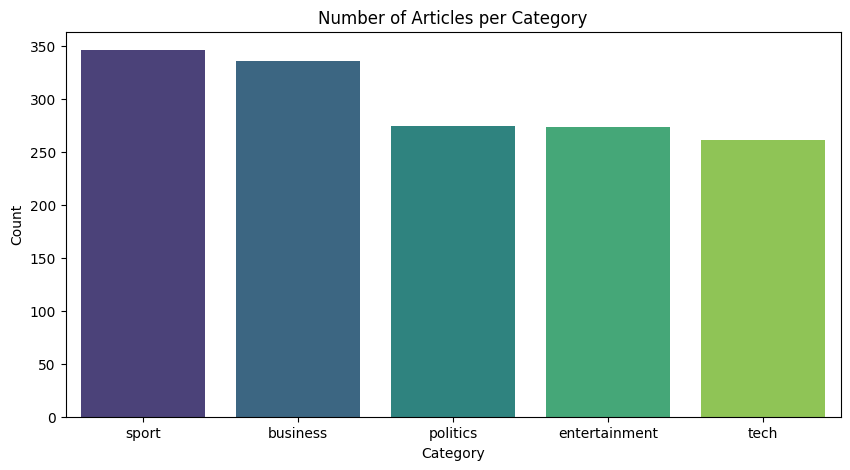

In [2]:
# 1. Load the datasets using the Kaggle paths provided
train_path = '/kaggle/input/learn-ai-bbc/BBC News Train.csv'
test_path = '/kaggle/input/learn-ai-bbc/BBC News Test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# 2. Initial Inspection
print("--- Training Data Preview ---")
print(train_df.head())

print("\n--- Dataset Info ---")
print(train_df.info())

# 3. Check for Missing Values
print("\n--- Missing Values ---")
print(train_df.isnull().sum())

# 4. Check Class Distribution
# It is important to see if any category is under-represented
category_counts = train_df['Category'].value_counts()
print("\n--- Category Distribution ---")
print(category_counts)

# 5. Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Number of Articles per Category')
plt.ylabel('Count')
plt.xlabel('Category')
plt.show()

In [3]:
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

# --- Phase 2: Label Encoding ---
label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df['Category'])

# Store the mapping so we can decode later
num_classes = len(label_encoder.classes_)
print(f"Mapped Classes: {list(label_encoder.classes_)}")

Mapped Classes: ['business', 'entertainment', 'politics', 'sport', 'tech']


In [4]:
# --- Phase 3: Tokenization ---
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

def encode_data(texts, max_length=256):
    input_ids = []
    attention_masks = []

    for text in texts:
        encoded_dict = tokenizer.encode_plus(
            text,                      # Sentence to encode
            add_special_tokens = True, # Add '[CLS]' and '[SEP]'
            max_length = max_length,   # Pad & truncate all sentences
            padding = 'max_length',
            truncation = True,
            return_attention_mask = True, # Construct attn. masks
            return_tensors = 'pt',     # Return pytorch tensors
        )
        
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])
    
    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0)

# We use 256 as a balance between performance and memory
X_train_ids, X_train_masks = encode_data(train_df['Text'].values)
y_train_labels = torch.tensor(train_df['label'].values)

print("Tokenization complete.")
print(f"Training shape: {X_train_ids.shape}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenization complete.
Training shape: torch.Size([1490, 256])


In [5]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# 1. Split the data (90% Train, 10% Validation)
train_inputs, val_inputs, train_labels, val_labels = train_test_split(
    X_train_ids, y_train_labels, test_size=0.1, random_state=42
)
train_masks, val_masks, _, _ = train_test_split(
    X_train_masks, y_train_labels, test_size=0.1, random_state=42
)

# 2. Create PyTorch Datasets
train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
val_dataset = TensorDataset(val_inputs, val_masks, val_labels)

# 3. Create DataLoaders
batch_size = 16 # Common choice for BERT fine-tuning

train_dataloader = DataLoader(
    train_dataset,
    sampler = RandomSampler(train_dataset), # Shuffle training data
    batch_size = batch_size
)

validation_dataloader = DataLoader(
    val_dataset,
    sampler = SequentialSampler(val_dataset), # No need to shuffle validation
    batch_size = batch_size
)

print(f"DataLoaders ready. Training batches: {len(train_dataloader)}")

DataLoaders ready. Training batches: 84


In [7]:
import torch
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW  # Changed import location

# Clear GPU cache to resolve the 'Unable to register' errors
torch.cuda.empty_cache()

# Load the pre-trained BERT model
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels = 5, 
    output_attentions = False,
    output_hidden_states = False,
)

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded successfully and moved to {device}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully and moved to cuda


In [8]:
import time
import datetime
import numpy as np

def format_time(elapsed):
    return str(datetime.timedelta(seconds=int(round((elapsed)))))

# Hyperparameters
epochs = 4
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

for epoch_i in range(0, epochs):
    print(f'\n======== Epoch {epoch_i + 1} / {epochs} ========')
    t0 = time.time()
    total_train_loss = 0
    model.train()

    for step, batch in enumerate(train_dataloader):
        if step % 40 == 0 and not step == 0:
            print(f'  Batch {step}  of  {len(train_dataloader)}.    Elapsed: {format_time(time.time() - t0)}.')

        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()        

        outputs = model(b_input_ids, 
                        token_type_ids=None, 
                        attention_mask=b_input_mask, 
                        labels=b_labels)
        
        loss = outputs.loss
        total_train_loss += loss.item()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)            
    print(f"\n  Average training loss: {avg_train_loss:.2f}")

    # --- Validation ---
    model.eval()
    total_eval_accuracy = 0

    for batch in validation_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)
        
        with torch.no_grad():        
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
        
        logits = outputs.logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        
        preds = np.argmax(logits, axis=1).flatten()
        total_eval_accuracy += np.sum(preds == label_ids)

    print(f"  Validation Accuracy: {total_eval_accuracy / len(val_dataset):.2f}")

print("\nTraining complete!")


======== Epoch 1 / 4 ========
  Batch 40  of  84.    Elapsed: 0:00:27.
  Batch 80  of  84.    Elapsed: 0:00:54.

  Average training loss: 0.82
  Validation Accuracy: 0.97

======== Epoch 2 / 4 ========
  Batch 40  of  84.    Elapsed: 0:00:29.
  Batch 80  of  84.    Elapsed: 0:01:01.

  Average training loss: 0.12
  Validation Accuracy: 0.99

======== Epoch 3 / 4 ========
  Batch 40  of  84.    Elapsed: 0:00:31.
  Batch 80  of  84.    Elapsed: 0:01:02.

  Average training loss: 0.04
  Validation Accuracy: 0.98

======== Epoch 4 / 4 ========
  Batch 40  of  84.    Elapsed: 0:00:31.
  Batch 80  of  84.    Elapsed: 0:01:03.

  Average training loss: 0.02
  Validation Accuracy: 0.99

Training complete!


In [9]:
# 1. Prepare the Test Data
test_texts = test_df['Text'].values
test_ids, test_masks = encode_data(test_texts) # Uses the function we wrote earlier

# 2. Predict in Batches (to avoid memory issues)
model.eval()
test_preds = []

# Using a simple loop for test inference
batch_size = 16
for i in range(0, len(test_ids), batch_size):
    batch_ids = test_ids[i:i+batch_size].to(device)
    batch_mask = test_masks[i:i+batch_size].to(device)
    
    with torch.no_grad():
        outputs = model(batch_ids, token_type_ids=None, attention_mask=batch_mask)
    
    logits = outputs.logits.detach().cpu().numpy()
    batch_preds = np.argmax(logits, axis=1).flatten()
    test_preds.extend(batch_preds)

# 3. Convert numeric labels back to text
final_labels = label_encoder.inverse_transform(test_preds)

# 4. Create Submission DataFrame
submission = pd.DataFrame({
    'ArticleId': test_df['ArticleId'],
    'Category': final_labels
})

# 5. Save to CSV
submission.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'!")
print(submission.head())

Submission file saved as 'submission.csv'!
   ArticleId  Category
0       1018     sport
1       1319      tech
2       1138     sport
3        459  business
4       1020     sport


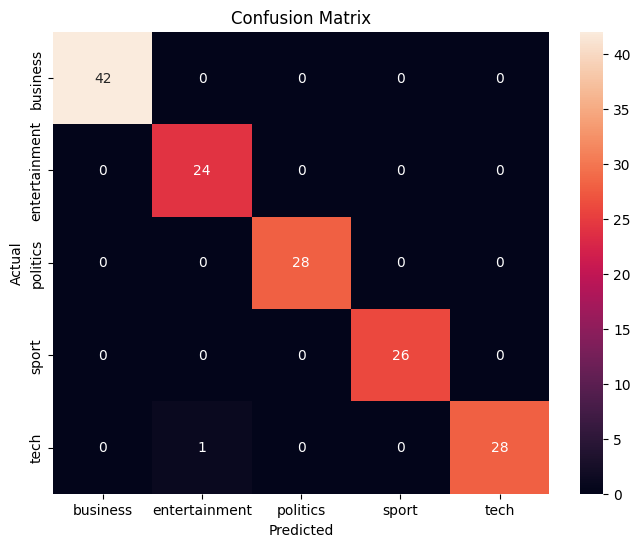

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for the validation set to build the matrix
val_preds = []
model.eval()
for batch in validation_dataloader:
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    with torch.no_grad():
        outputs = model(b_input_ids, attention_mask=b_input_mask)
    logits = outputs.logits.detach().cpu().numpy()
    val_preds.extend(np.argmax(logits, axis=1).flatten())

# Plotting
cm = confusion_matrix(val_labels.cpu().numpy(), val_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()